In [ ]:
!pip install -q ultralytics

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

In [ ]:
cap = cv2.VideoCapture("/content/football_jersey_clip.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
ret,frame = cap.read()
ret2, frame2 = cap.read()

In [ ]:
def get_centroids(frame):
  result = model.track(frame, persist=True, verbose=False)
  boxes = result[0].boxes.xyxy.cpu().numpy()
  conf = result[0].boxes.conf.cpu().numpy()
  if result[0].boxes.id is None:
    return []
  ids = result[0].boxes.id.cpu().numpy()
  centroid = []
  for box, c, tid in zip(boxes, conf, ids):
    if c < 0.5:
      continue
    x1, y1, x2, y2 = box
    cx = (x1+x2)/2
    cy = (y1+y2)/2
    centroid.append((cx, cy, tid))
  return centroid

test_centroids = get_centroids(frame)
print("get_centroids output:", test_centroids)

get_centroids output: [(np.float32(403.42545), np.float32(304.4803), np.float32(376.0)), (np.float32(99.70708), np.float32(275.87146), np.float32(377.0)), (np.float32(589.9822), np.float32(353.16367), np.float32(378.0))]


In [ ]:
# grab raw boxes once here so jersey-crop/avg-color tests have real data to use
_test_result = model.track(frame, persist=True, verbose=False)
_test_boxes = _test_result[0].boxes.xyxy.cpu().numpy()
print("Sample box for testing:", _test_boxes[0] if len(_test_boxes) else "none detected")

Sample box for testing: [     390.59      284.11      416.26      324.85]


In [ ]:
def get_jersey_crop(frame, box):
    x1, y1, x2, y2 = map(int, box)
    height = y2 - y1
    new_y2 = int(y1 + (0.35 * height))
    return frame[y1:new_y2, x1:x2]

test_crop = get_jersey_crop(frame, _test_boxes[0])
print("get_jersey_crop output shape:", test_crop.shape)

get_jersey_crop output shape: (14, 26, 3)


In [ ]:
def get_avg_color(crop):
  return crop.mean(axis=(0,1))

test_color = get_avg_color(test_crop)
print("get_avg_color output:", test_color)

get_avg_color output: [      109.7       162.7      140.86]


In [ ]:
import math
def get_player_speeds(position_history, fps):
  speeds = []
  for i in range(1, len(position_history)):
    f1,x1, y1 = position_history[i-1]
    f2,x2, y2 = position_history[i]
    gap = f2-f1
    if gap != 1 :
      continue
    distance = math.sqrt((x2-x1)**2 + (y2-y1)**2)
    speed = distance*fps
    if speed>12:
      continue
    speeds.append(speed)
  return speeds

test_speeds = get_player_speeds([(1,0,0),(2,10,0),(5,10,10)], fps=30)
print("get_player_speeds output:", test_speeds)

get_player_speeds output: []


In [ ]:
def count_sprints(speeds,threshold,min_frames = 10):
  sprint_count = 0
  run = 0
  for s in speeds:
    if s>threshold:
      run +=1
    else:
      run = 0

    if run == min_frames:
      sprint_count +=1

  return sprint_count

# one sprint expected: 30 fast frames, then 5 slow
print(count_sprints([8]*30 + [5]*5, 7))

1


In [ ]:
import numpy as np

# average each point's x and y with its neighbours, keeping the real frame number
def smooth_positions(points, window=5):
    half = window // 2
    smoothed = []
    for i in range(half, len(points) - half):
        chunk = points[i-half : i+half+1]
        avg_x = np.mean([p[1] for p in chunk])
        avg_y = np.mean([p[2] for p in chunk])
        smoothed.append((points[i][0], avg_x, avg_y))
    return smoothed

In [ ]:
def build_player_summary(players_position, player_team, player_distances, fps, sprint_threshold):
  player_summary = {}
  for player_id, pos_history in players_position.items():
    team = player_team.get(player_id, "unknown")
    if not isinstance(team, str):
      team = team.item()
    distance = player_distances[player_id]
    speed = get_player_speeds(pos_history, fps)
    sprint_count = count_sprints(speed, sprint_threshold)
    player_summary[player_id] = {
        "team": team,
        "distance": distance,
        "speed": speed,
        "sprint_count": sprint_count
    }
  return player_summary



In [ ]:
model = YOLO('yolov8n.pt')
players_position = {}
tid_color ={}
prev_ids = set()
cap = cv2.VideoCapture("/content/football_jersey_clip.mp4")
frame_count = 0
max_frames = 705

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    if frame_count > max_frames:
        break

    centroid = get_centroids(frame)
    result = model.track(frame, persist=True, verbose=False)
    boxes = result[0].boxes.xyxy.cpu().numpy()
    ids = result[0].boxes.id.cpu().numpy() if result[0].boxes.id is not None else []
    for box, tid in zip(boxes, ids):
        crop = get_jersey_crop(frame, box)
        tid_color[tid] = get_avg_color(crop)
    curr_ids = { tid for cx, cy, tid in centroid }

    for cx, cy, tid in centroid:
        if tid in players_position:
          players_position[tid].append((frame_count,cx, cy))

        else:
            players_position[tid] = [(frame_count,cx, cy)]
    disappeared = prev_ids - curr_ids
    new_ids = curr_ids - prev_ids
    if new_ids:
      for t1 in new_ids:
          for t2 in disappeared:
              if t1 not in players_position or t2 not in players_position:
                continue
              dist = np.linalg.norm(tid_color[t1] - tid_color[t2])
              if dist < 15:
                players_position[t2] = players_position[t2]+players_position[t1]
                del players_position[t1]
                print("MATCH:", t1, t2)
                break
              print(t1, t2, dist)
    prev_ids = curr_ids

print("Main loop done. Total tracked ids:", len(players_position))

386.0 380.0 21.57750247809585
380.0 384.0 51.290050602707595
MATCH: 383.0 382.0
387.0 383.0 15.646387993314596
383.0 379.0 19.55375632922316
391.0 379.0 63.18515335467183
391.0 390.0 64.66588511445251
388.0 379.0 48.66152404861862
403.0 400.0 15.437850310915117
403.0 390.0 32.55567972321711
388.0 390.0 81.51603426718657
407.0 400.0 43.8574117851599
404.0 407.0 40.80059634543632
407.0 404.0 36.975063638268615
403.0 411.0 22.439931817515273
403.0 411.0 22.25555017266846
411.0 410.0 24.257873113550303
410.0 405.0 36.43709668346751
410.0 407.0 27.982913706476907
410.0 411.0 17.84037142722496
405.0 411.0 50.296932796262205
411.0 390.0 33.955084232070675
405.0 390.0 21.807828655331534
403.0 411.0 27.939102822484294
405.0 411.0 38.29865489711717
MATCH: 408.0 406.0
405.0 406.0 27.655363495362995
406.0 405.0 23.118253365237628
413.0 406.0 27.715338100094232
414.0 406.0 65.2635593864036
413.0 403.0 49.645980440626595
413.0 405.0 21.814891860913576
MATCH: 414.0 403.0
414.0 405.0 49.67776186244891

In [ ]:
players_position = {pid: pos for pid, pos in players_position.items() if len(pos) >= 5}

(772, 1366, 3)


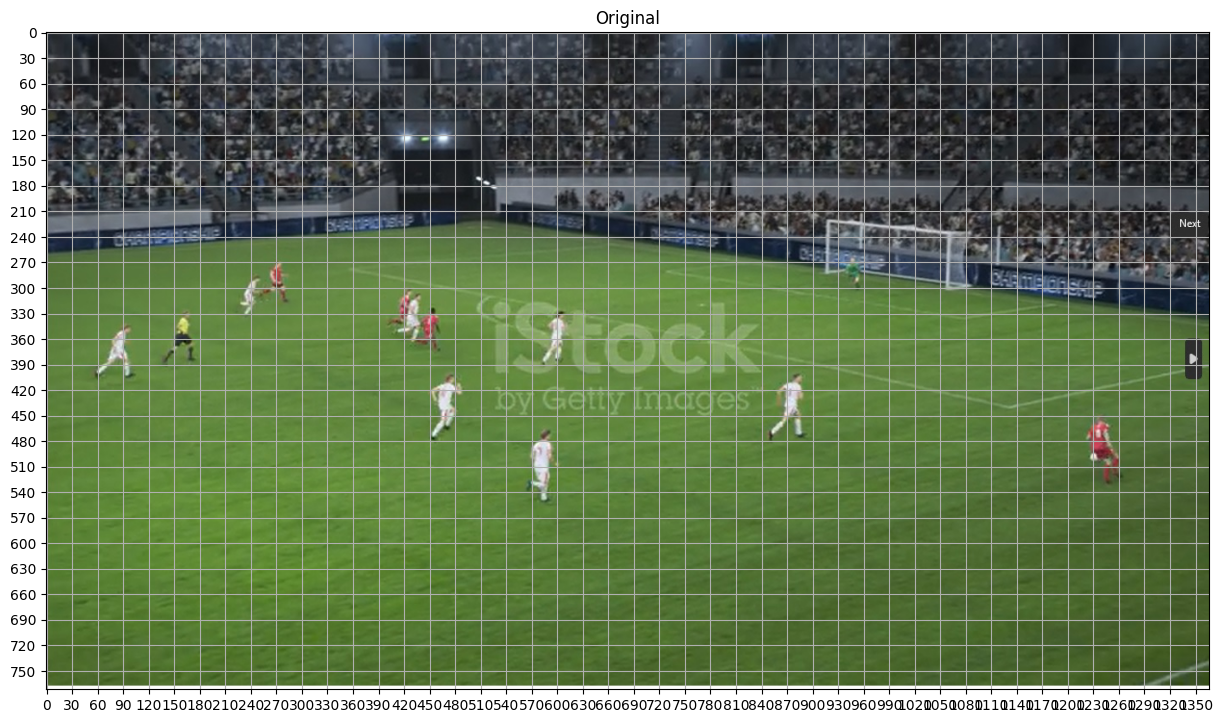

In [ ]:
def image_ball(img_path):
  img = cv2.imread(img_path)
  plt.figure(figsize=(15,10))
  plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
  plt.grid(True)
  print(img.shape)
  plt.xticks(range(0, img.shape[1], 30))
  plt.yticks(range(0, img.shape[0], 30))
  plt.title("Original")

detection = image_ball("/content/Tactical_viewofmatch.jpg")

In [ ]:
# calibration points: P1,P2 = 18-yard line corners; P5,P6 = six-yard box corners
pixel_pts = np.float32([[360,279],[1132,441],[727,282],[1079,336]])
real_pts = np.float32([[88.5,53.68],[88.5,14.32],[99.5,43.16],[99.5,24.84]])

matrix = cv2.getPerspectiveTransform(pixel_pts, real_pts)
print(matrix)

[[  -0.072555    -0.71847      15.654]
 [   0.064468    0.099631     -178.94]
 [ 2.9132e-05   -0.012164           1]]


In [ ]:
penalty_pt = np.array([[[771, 320]]], dtype=np.float32)
real_penalty_pt = cv2.perspectiveTransform(penalty_pt, matrix)[0][0]

known_pt = np.float32([94, 34])
distance_error = np.linalg.norm(real_penalty_pt - known_pt)
print("Error (m):", distance_error)

Error (m): 0.16491592


In [ ]:
# converts one pixel point to world meters using the calibration matrix
def pixel_to_world(point, matrix):
    x, y = point
    pixel_arr = np.array([[[x, y]]], dtype=np.float32)
    transformed = cv2.perspectiveTransform(pixel_arr, matrix)
    return transformed[0][0]

In [ ]:
# converts every player's full pixel history into world-meter coordinates
players_position_world = {}
for tid, history in players_position.items():
    converted_points = []
    for frame,x, y in history:
        world_point = pixel_to_world((x, y), matrix)
        packed = (frame,world_point[0],world_point[1])
        converted_points.append(packed)
    players_position_world[tid] = converted_points

In [ ]:
# checks how many converted points fall outside a realistic pitch range
x_min, x_max = -5, 110
y_min, y_max = -5, 73
bad_count = 0
total_count = 0
for tid, points in players_position_world.items():
    for frame,x, y in points:
        total_count += 1
        if not (x_min <= x <= x_max and y_min <= y <= y_max):
            bad_count += 1
print(bad_count, total_count, bad_count/total_count*100)

2178 4870 44.72279260780287


In [ ]:
players_position_valid = {}

for tid,point in players_position_world.items():
  valid_point = []
  for frame,x,y in point:
    # keep the point only if it lies inside the pitch bounds
    if x_min <= x <= x_max and y_min <= y <= y_max:
      valid_point.append((frame,x, y))
  players_position_valid[tid]=valid_point

print(len(players_position_world))
print(len(players_position_valid))

# confirm real frame numbers (with gaps) survived the filter
print(list(players_position_valid.items())[0][1][:5])

54
54
[(1, np.float32(86.32301), np.float32(45.54168)), (2, np.float32(86.32272), np.float32(45.54467)), (3, np.float32(86.33806), np.float32(45.58454)), (4, np.float32(86.331345), np.float32(45.572983)), (5, np.float32(86.31763), np.float32(45.5634))]


In [ ]:
# drop players who have no valid points left
players_position_clean = {}
for tid, points in players_position_valid.items():
    if len(points) > 0:
        players_position_clean[tid] = points
print(len(players_position_clean))

35


In [ ]:
players_position_smooth = {}

for tid, points in players_position_clean.items():
    smoothed = smooth_positions(points)
    if len(smoothed) > 0:  # keeps only non-empty histories
        players_position_smooth[tid] = smoothed

print(len(players_position_smooth))

33


In [ ]:
# distances in meters: same loop, but over the smoothed meter data
player_distances = {}
for pid, history in players_position_smooth.items():
    total = 0
    for i in range(len(history) - 1):
        f1,x1, y1 = history[i]
        f2,x2, y2 = history[i+1]
        # frames between two neighbouring points; 1 means no frames were skipped
        gap = f2 - f1
        if gap !=1:
          continue
        d = ((x2-x1)**2 + (y2-y1)**2)**0.5
        total += d
    player_distances[pid] = total
print(player_distances)

{np.float32(379.0): np.float32(31.430155), np.float32(380.0): np.float32(39.612938), np.float32(381.0): np.float32(13.029197), np.float32(382.0): np.float32(43.988407), np.float32(386.0): np.float32(20.51852), np.float32(383.0): np.float32(0.67588943), np.float32(388.0): np.float32(1.7932987), np.float32(389.0): np.float32(28.367945), np.float32(399.0): np.float32(2.5635705), np.float32(406.0): np.float32(53.757645), np.float32(411.0): np.float32(7.30252), np.float32(408.0): np.float32(35.741146), np.float32(413.0): np.float32(19.906797), np.float32(414.0): np.float32(12.210259), np.float32(420.0): np.float32(20.364912), np.float32(421.0): np.float32(8.154585), np.float32(422.0): np.float32(26.311047), np.float32(424.0): np.float32(13.064462), np.float32(426.0): np.float32(30.931116), np.float32(427.0): np.float32(2.646467), np.float32(428.0): np.float32(8.656017), np.float32(429.0): np.float32(28.352015), np.float32(431.0): np.float32(1.827911), np.float32(432.0): np.float32(1.1765572

In [ ]:
colors_only = list(tid_color.values())
ids_only = list(tid_color.keys())
data = np.array(colors_only, dtype=np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
compactness, labels, centers = cv2.kmeans(data, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
player_team = {tid: labels[i][0] for i, tid in enumerate(ids_only)}
print(player_team)

{np.float32(379.0): np.int32(1), np.float32(380.0): np.int32(0), np.float32(381.0): np.int32(1), np.float32(382.0): np.int32(1), np.float32(383.0): np.int32(1), np.float32(384.0): np.int32(1), np.float32(385.0): np.int32(1), np.float32(386.0): np.int32(0), np.float32(387.0): np.int32(0), np.float32(388.0): np.int32(0), np.float32(389.0): np.int32(0), np.float32(390.0): np.int32(1), np.float32(391.0): np.int32(0), np.float32(398.0): np.int32(0), np.float32(399.0): np.int32(0), np.float32(400.0): np.int32(0), np.float32(402.0): np.int32(1), np.float32(403.0): np.int32(0), np.float32(404.0): np.int32(1), np.float32(405.0): np.int32(0), np.float32(406.0): np.int32(1), np.float32(407.0): np.int32(1), np.float32(408.0): np.int32(1), np.float32(410.0): np.int32(1), np.float32(411.0): np.int32(0), np.float32(413.0): np.int32(1), np.float32(414.0): np.int32(0), np.float32(415.0): np.int32(0), np.float32(417.0): np.int32(1), np.float32(418.0): np.int32(1), np.float32(419.0): np.int32(1), np.floa

In [ ]:
team_distance = {}
for pid, dist in player_distances.items():
  if pid not in player_team:
    continue
  team = int(player_team[pid])
  if team not in team_distance:
    team_distance[team] = 0
  team_distance[team] += dist
print(team_distance)

{1: np.float32(239.43452), 0: np.float32(390.59613)}


In [ ]:
# summary on smoothed meter data, sprint threshold in m/s
fps = cap.get(cv2.CAP_PROP_FPS)
summary = build_player_summary(players_position_smooth, player_team, player_distances, fps, 7)
print(len(summary))

33


In [ ]:
summary_clean = {}
for pid,card in summary.items():
  if len(card['speed']) >=25:
    summary_clean[pid]=card

print(len(summary_clean))

22


In [ ]:
# sort players by distance, biggest first
ranked = sorted(summary_clean.items(), key=lambda item: item[1]["distance"], reverse=True)
print(len(ranked))

22


In [ ]:
sliced = ranked[:5]
for pid,card in sliced:
  print(f"{int(pid)},{card['team']},{card['distance']:.1f},{card['sprint_count']}")

438,0,71.2,1
406,1,53.8,3
443,0,44.5,0
382,1,44.0,0
380,0,39.6,0
